In [ ]:
library(ggplot2)  # For making plots
library(tidyr)    # For reshaping data (wide to long format)
library(dplyr)    # For data manipulation (select, filter, etc.)
library(e1071)    # For skewness() function


In [18]:
# Define consistent color palette for wetland classes
class_colors <- c("Bog" = "#F8766D",      # Red/coral
                  "Fen" = "#7CAE00",      # Green
                  "Marsh" = "#00BFC4",    # Cyan/blue
                  "Swamp" = "#C77CFF")    # Purple

df <- read.csv("C:/Users/Leila/DropBox/MayoWetlands/wetland_alldata_2025_only_uscore.csv")


# Chemistry 

Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windows

Warning message:
"Removed 648 rows containing non-finite values (`stat_boxplot()`)."
Warning message:
"Removed 648 rows containing non-finite values (`stat_boxplot()`)."
Warning message:
"Removed 120 rows containing non-finite values (`stat_boxplot()`)."


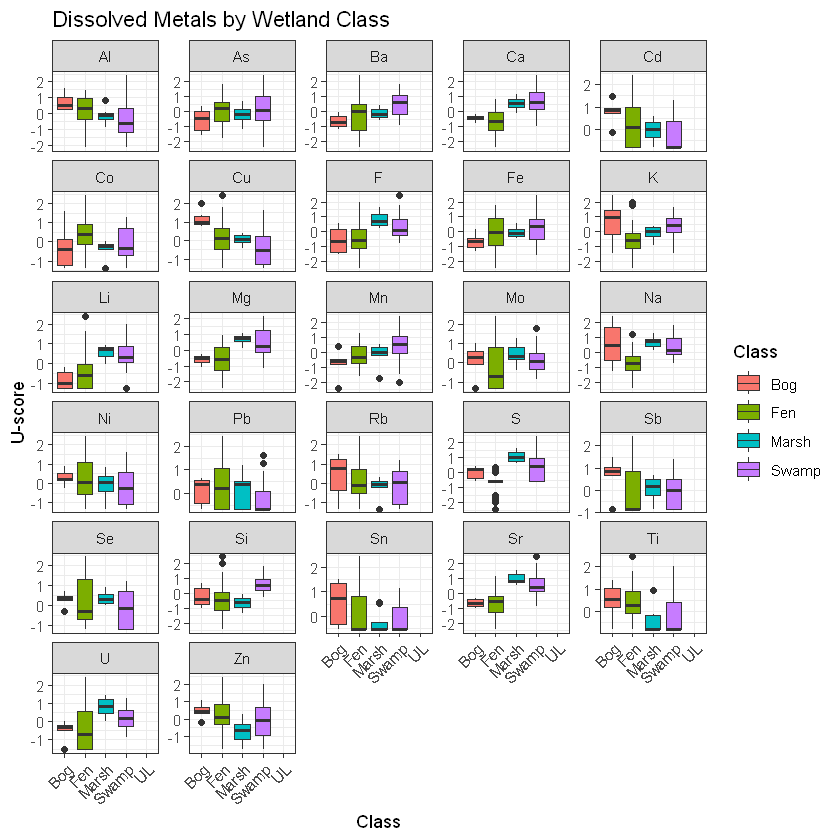

Warning message:
"Removed 120 rows containing non-finite values (`stat_boxplot()`)."
Warning message:
"Removed 96 rows containing non-finite values (`stat_boxplot()`)."


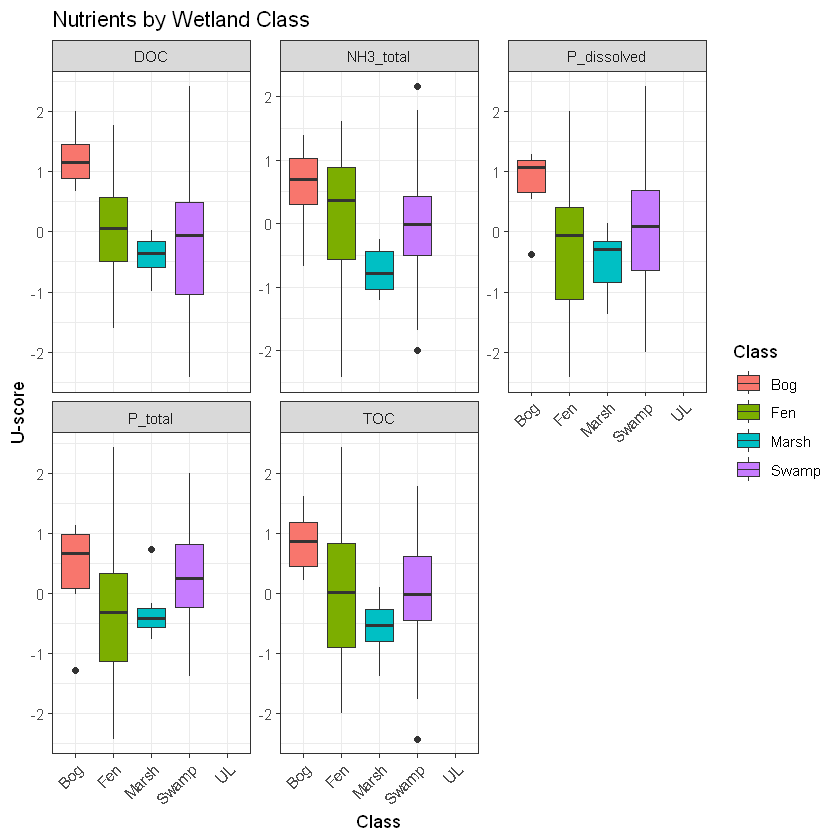

Warning message:
"Removed 96 rows containing non-finite values (`stat_boxplot()`)."
Warning message:
"Removed 120 rows containing non-finite values (`stat_boxplot()`)."


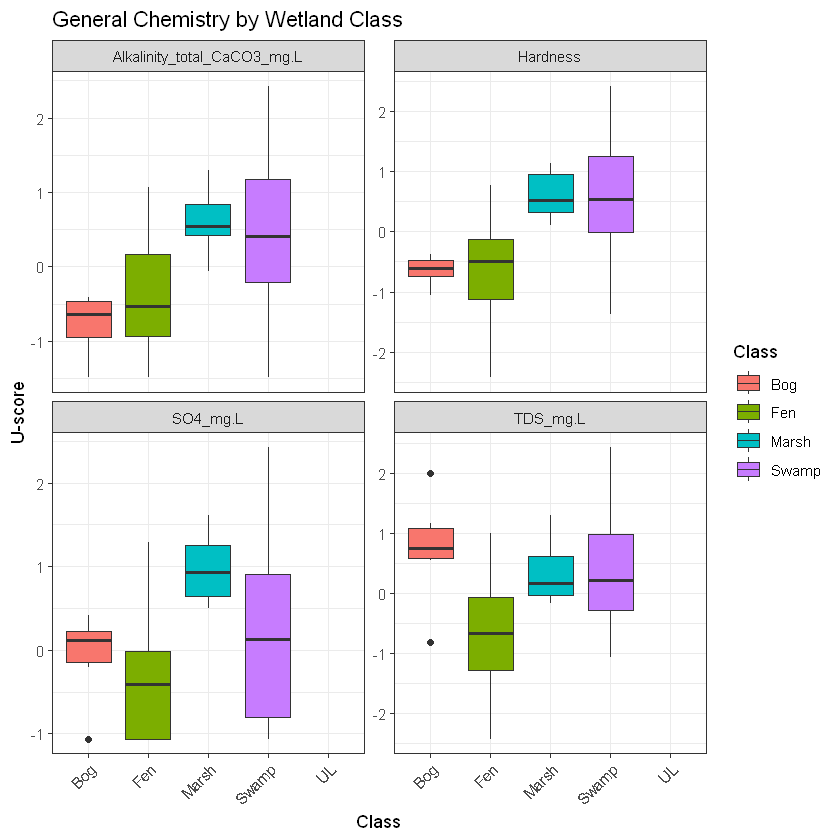

Warning message:
"Removed 120 rows containing non-finite values (`stat_boxplot()`)."


<U+2713> Saved 4 chemistry group plots to Figures/

=== SEVERELY SKEWED VARIABLES (|skewness| > 2) ===
[1] variable class    skewness n        severity
<0 rows> (or 0-length row.names)

=== MODERATELY SKEWED VARIABLES (|skewness| 1-2) ===
              variable class  skewness  n severity
1  Dissolved_O_percent Swamp  1.964934 27 Moderate
2  Dissolved_O_percent   Fen  1.725578 25 Moderate
3                   pH Swamp -1.619230 27 Moderate
4                  SpC Marsh  1.426282  8 Moderate
5      Dissolved_O_mgL   Fen  1.401245 25 Moderate
6                   Co Marsh -1.354506  8 Moderate
7                   Rb Marsh -1.293804  8 Moderate
8                   Pb Swamp  1.290718 27 Moderate
9                   Mn Marsh -1.281075  8 Moderate
10             P_total Marsh  1.196708  8 Moderate
11                  Ti Marsh  1.181732  8 Moderate
12                  Li   Fen  1.149892 25 Moderate
13     Dissolved_O_mgL Swamp  1.119144 27 Moderate
14                  Ti Swamp  1.098788 27 Moder

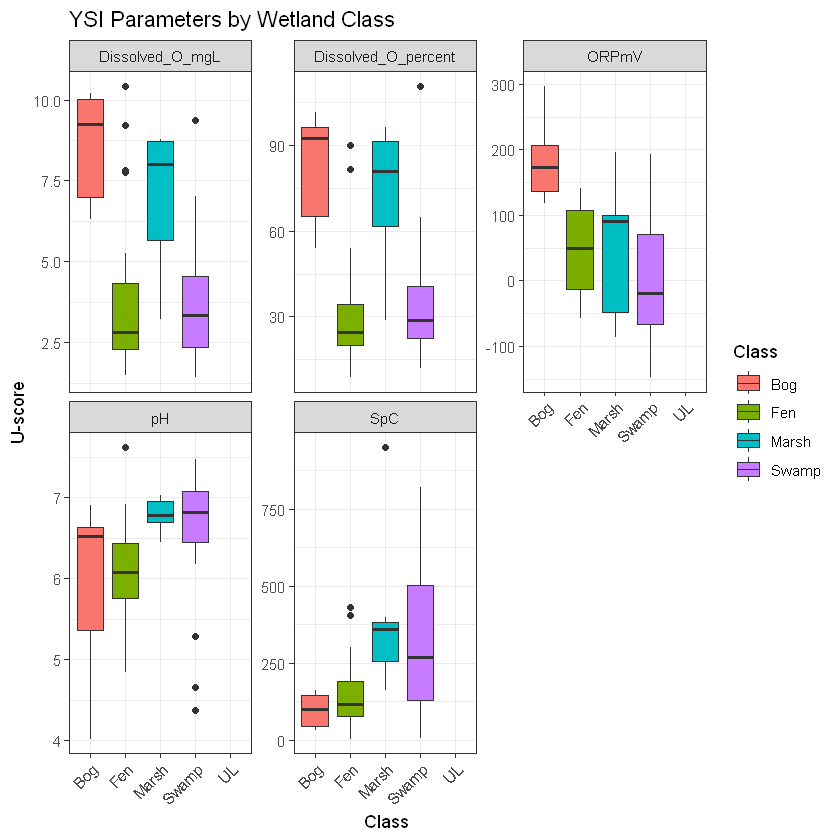

In [ ]:
# ==== GROUP 1: DISSOLVED METALS ====
metals <- c("Al", "Sb", "As", "Ba", "Be", "Bi", "B", "Cd", "Ca", "Cs", "Cr", 
            "Co", "Cu", "F", "Fe", "Pb", "Li", "Mg", "Mn", "Mo", "Ni", "P", 
            "K", "Rb", "Se", "Si", "Ag", "Na", "Sr", "S", "Te", "Tl", "Th", 
            "Sn", "Ti", "W", "U", "V", "Zn", "Zr")
metals <- metals[metals %in% names(df)]

metals_long <- df %>%
  select(Class, all_of(metals)) %>%
  pivot_longer(cols = -Class, names_to = "variable", values_to = "value")

ggplot(metals_long, aes(x = Class, y = value, fill = Class)) +
  geom_boxplot() +
  scale_fill_manual(values = class_colors) + 
  facet_wrap(~ variable, scales = "free_y", ncol = 5) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Dissolved Metals by Wetland Class", y = "U-score")

ggsave("Figures/02_metals_distributions.png", width = 18, height = 12)

# ==== GROUP 2: NUTRIENTS ====
nutrients <- c("NH3_total", "TOC", "DOC", "P_total", "P_dissolved")
nutrients <- nutrients[nutrients %in% names(df)]

nutrients_long <- df %>%
  select(Class, all_of(nutrients)) %>%
  pivot_longer(cols = -Class, names_to = "variable", values_to = "value")

ggplot(nutrients_long, aes(x = Class, y = value, fill = Class)) +
  geom_boxplot() +
  scale_fill_manual(values = class_colors) + 
  facet_wrap(~ variable, scales = "free_y", ncol = 3) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Nutrients by Wetland Class", y = "U-score")

ggsave("Figures/03_nutrients_distributions.png", width = 10, height = 6)

# ==== GROUP 3: GENERAL CHEMISTRY ====
general <- c("Alkalinity_total_CaCO3_mg.L", "TDS_mg.L", "Hardness", "SO4_mg.L")
general <- general[general %in% names(df)]

general_long <- df %>%
  select(Class, all_of(general)) %>%
  pivot_longer(cols = -Class, names_to = "variable", values_to = "value")

ggplot(general_long, aes(x = Class, y = value, fill = Class)) +
  geom_boxplot() +
  scale_fill_manual(values = class_colors) + 
  facet_wrap(~ variable, scales = "free_y", ncol = 2) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "General Chemistry by Wetland Class", y = "U-score")

ggsave("Figures/04_general_chem_distributions.png", width = 8, height = 6)

# ==== GROUP 4: YSI PARAMETERS ====
ysi <- c("Dissolved_O_percent", "Dissolved_O_mgL", "pH", "SpC", "ORPmV")
ysi <- ysi[ysi %in% names(df)]

ysi_long <- df %>%
  select(Class, all_of(ysi)) %>%
  pivot_longer(cols = -Class, names_to = "variable", values_to = "value")

ggplot(ysi_long, aes(x = Class, y = value, fill = Class)) +
  geom_boxplot() +
  scale_fill_manual(values = class_colors) + 
  facet_wrap(~ variable, scales = "free_y", ncol = 3) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "YSI Parameters by Wetland Class", y = "U-score")

ggsave("Figures/05_ysi_distributions.png", width = 10, height = 6)

cat("✓ Saved 4 chemistry group plots to Figures/\n")

#==========================================================================
# Calc Skewness 
#==========================================================================
# Calculate skewness for all chemistry variables

# Define all chemistry groups
all_chem <- c(metals, nutrients, general, ysi)

# Calculate skewness by class
skewness_results <- data.frame()

for(var in all_chem) {
  if(var %in% names(df)) {
    for(class in unique(df$Class)) {
      values <- df %>% filter(Class == class) %>% pull(var)
      values <- values[!is.na(values)]
      
      if(length(values) > 2) {  # Need at least 3 values
        skew_val <- skewness(values)
        
        skewness_results <- rbind(skewness_results, 
                                  data.frame(variable = var,
                                            class = class,
                                            skewness = skew_val,
                                            n = length(values)))
      }
    }
  }
}

# Flag highly skewed (|skewness| > 1 = moderate, >2 = severe)
skewness_results$severity <- ifelse(abs(skewness_results$skewness) > 2, "Severe",
                                     ifelse(abs(skewness_results$skewness) > 1, "Moderate", "Mild"))

# View severely skewed variables
cat("\n=== SEVERELY SKEWED VARIABLES (|skewness| > 2) ===\n")
severe <- skewness_results %>% 
  filter(severity == "Severe") %>%
  arrange(desc(abs(skewness)))
print(severe)

# View moderately skewed
cat("\n=== MODERATELY SKEWED VARIABLES (|skewness| 1-2) ===\n")
moderate <- skewness_results %>% 
  filter(severity == "Moderate") %>%
  arrange(desc(abs(skewness)))
print(moderate)



# TRY AVERAGING CHEMISTRY DATA

## Boxplot findings

03 metals
- Most symmetric and well-separated
- K: Has outliers (Bog and Fen)
- S: Several outliers in Marsh

04 nutrients
- All symmetric, good separation
- NH3_total: Has outliers top and bottom
- Minimal skewness overall

04 gen chem 
- TDS is higher in bogs likely due to water sampling method = justification for dropping TDS
- Alkalinity and hardness separates bog and fen from marsh and swamp
- SO4 means are sep across classes
- None are highly skewed

05 ysi
- pH: bog is skewed with outlier, and overlapping with fen (altough not the means are not)
- pH: Marsh and swamp have overlapping means separa from Bog and Fen
- SpC: Marsh is skewed, swamp has a large range and outlier. Bog and Fen overlap but not the means
- DO[] and DO% show the same distribution and separates them all most bog and Marsh from Swamp and Fen
- ORP: marsh highly skewed means are separate in Fen, Marsh, and Swamp and 3 are very separate from Bog

## Skewness Assessment

- No severely skewed variables (|skewness| > 2)
- 15/41 moderately skewed (|skewness| 1-2):
  - Dissolved O in Swamp/Fen (1.4-2.0) 
  - SpC in Marsh (1.4) - reflects water source heterogeneity
  - Trace metals (Co, Rb, Pb, Mn, Ti, Li, U) show slight skew (1.1-1.4) - typical for low-concentration elements
  - pH in Swamp (-1.6) - mild negative skew
- **Decision**: Proceed with RDA using scale = TRUE. Skewness levels are acceptable and reflect real ecological variation rather than data quality issues.



# UAV Vegetation Structure

Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windows

Wetland sites (unique): 66 
Classes: Swamp, Fen, Marsh, Bog 

=== STRUCTURE: SEVERELY SKEWED (|skewness| > 2) ===
       variable class skewness  n severity
1 CanopyCover1m   Fen    4.416 25   Severe

=== STRUCTURE: MODERATELY SKEWED (|skewness| 1-2) ===
             variable class  skewness  n severity
1        stem_density Swamp  1.867537 27 Moderate
2      P25_veg_height Swamp  1.864299 27 Moderate
3   median_veg_height Swamp  1.862152 27 Moderate
4       CanopyCover2m Swamp  1.860441 27 Moderate
5       CanopyCover2m Marsh  1.856155  8 Moderate
6        stem_density Marsh  1.856155  8 Moderate
7       CanopyCover1m Marsh  1.855508  8 Moderate
8      P75_veg_height Swamp  1.850987 27 Moderate
9       CanopyCover1m Swamp  1.850133 27 Moderate
10 average_veg_height Swamp  1.809018 27 Moderate
11     P25_veg_height Marsh -1.778595  8 Moderate
12     max_veg_height Marsh  1.688584  8 Moderate
13     P95_veg_height Swamp  1.688031 27 Moderate
14  stddev_veg_height Marsh  1.506368  8 Mode

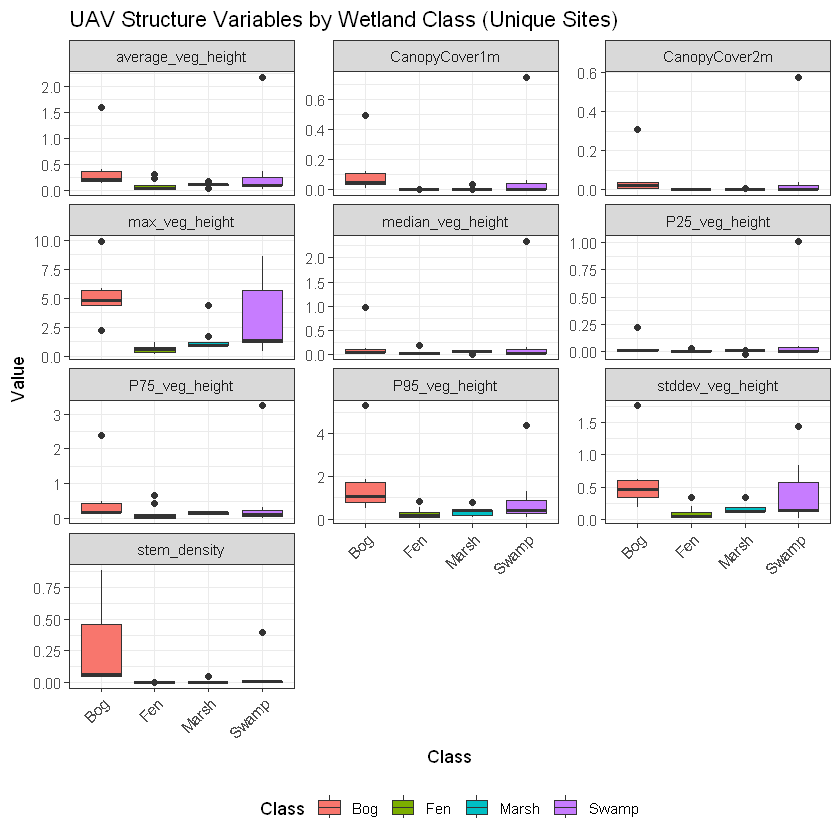

In [20]:
# ============================================================================
# Cell 3: UAV Structure (ONE OBSERVATION PER SITE)
# ============================================================================

# Filter: Wetlands only + unique sites (UAV measured once per site)
df_wetland_unique <- df %>% 
  filter(Class != "UL") %>%
  group_by(SiteID) %>%
  slice(1) %>%
  ungroup()

cat("Wetland sites (unique):", nrow(df_wetland_unique), "\n")
cat("Classes:", paste(unique(df_wetland_unique$Class), collapse = ", "), "\n")

# UAV Structure variables
structure_vars <- c("average_veg_height", "median_veg_height", "max_veg_height",
                    "stddev_veg_height", "P95_veg_height", "P75_veg_height", "P25_veg_height",
                    "CanopyCover1m", "CanopyCover2m", "stem_density")

structure_vars <- structure_vars[structure_vars %in% names(df_wetland_unique)]

structure_long <- df_wetland_unique %>%
  select(Class, all_of(structure_vars)) %>%
  pivot_longer(cols = -Class, names_to = "variable", values_to = "value")

# Boxplot
ggplot(structure_long, aes(x = Class, y = value, fill = Class)) +
  geom_boxplot() +
  scale_fill_manual(values = class_colors) + 
  facet_wrap(~ variable, scales = "free_y", ncol = 3) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom") +
  labs(title = "UAV Structure Variables by Wetland Class (Unique Sites)",
       y = "Value")

ggsave("Figures/06_structure_distributions.png", width = 12, height = 10)

# Skewness calculation (on unique sites)
skewness_structure <- data.frame()

for(var in structure_vars) {
  if(var %in% names(df_wetland_unique)) {
    for(class in unique(df_wetland_unique$Class)) {
      values <- df_wetland_unique %>% filter(Class == class) %>% pull(var)
      values <- values[!is.na(values)]
      
      if(length(values) > 2) {
        skew_val <- skewness(values)
        
        skewness_structure <- rbind(skewness_structure, 
                                    data.frame(variable = var,
                                              class = class,
                                              skewness = skew_val,
                                              n = length(values)))
      }
    }
  }
}

skewness_structure$severity <- ifelse(abs(skewness_structure$skewness) > 2, "Severe",
                                       ifelse(abs(skewness_structure$skewness) > 1, "Moderate", "Mild"))

cat("\n=== STRUCTURE: SEVERELY SKEWED (|skewness| > 2) ===\n")
print(skewness_structure %>% filter(severity == "Severe") %>% arrange(desc(abs(skewness))))

cat("\n=== STRUCTURE: MODERATELY SKEWED (|skewness| 1-2) ===\n")
print(skewness_structure %>% filter(severity == "Moderate") %>% arrange(desc(abs(skewness))))

# write.csv(skewness_structure, "Figures/08_skewness_structure_CORRECTED.csv", row.names = FALSE)
cat("\n✓ Corrected for multiple observations per site\n")

## Veg struct findings

Most classes have low vegetation structure. But bogs have slight higher veg heights and stem density values. Bogs also have a much greater vegetation height variation than the other three. 

Average_veg_height has one major outlier in the swamp class - which ELA

Conclusion:
-----------
- Most wetlands show very low vegetation structure (median height <0.2m)
- Fen, Marsh, Swamp are indistinguishable by structure (all herbaceous/open)
- Structure variables alone insufficient for wetland classification
  - Need spectral variables (NDVI, NIR) to distinguish herbaceous wetland types